# Shapley Attribution — Feature Walkthrough

End-to-end notebook covering:
1. Synthetic data generation (with known ground truth)
2. Fitting all models (Shapley-based + heuristic baselines)
3. Visualizations: attribution bars, journey diagrams, heatmaps
4. Multi-model comparison and performance metrics
5. scikit-learn API compatibility
6. Scalability

> **Note:** If imports fail after pulling new code, restart the kernel to clear the module cache.

## 1. Imports

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 110

from shapley_attribution import (
    # Models
    MonteCarloShapleyAttribution,
    PathShapleyAttribution,
    SimplifiedShapleyAttribution,
    OrderedShapleyAttribution,
    # Baselines
    FirstTouchAttribution,
    LastTouchAttribution,
    LinearAttribution,
    TimeDecayAttribution,
    PositionBasedAttribution,
    # Data
    make_attribution_problem,
    # Metrics
    normalized_mean_absolute_error,
    rank_correlation,
    top_k_overlap,
    attribution_summary,
    # Visualization
    plot_attribution,
    compare_models,
    plot_performance,
    plot_journey,
    plot_journeys_heatmap,
    plot_position_attribution,
)

print('All imports OK')

All imports OK


---
## 2. Synthetic Data Generation

`make_attribution_problem` generates a realistic attribution dataset with **known ground truth**:

1. Channel importances are drawn from a Dirichlet distribution (α=2, power=1.3) — moderate skew, 1–2 dominant channels.
2. A logistic conversion model is built from those importances + random pairwise interaction terms.
3. An intercept is calibrated to hit the target conversion rate.
4. Journeys are generated with **near-uniform channel sampling** — frequency carries no signal, only which *combinations* drive conversion matters.
5. Each journey is labelled converting/not via a Bernoulli draw from the logistic model.

Ground truth = the normalized individual channel importance weights (step 1).

In [2]:
journeys, conversions, ground_truth, channel_names = make_attribution_problem(
    n_channels=8,
    n_journeys=5000,
    max_journey_length=6,
    interaction_effects=0.5,
    base_conversion_rate=0.3,
    random_state=42,
)

n_converting = conversions.sum()
print(f"Journeys     : {len(journeys):,}")
print(f"Conversions  : {n_converting:,} / {len(journeys):,}  ({conversions.mean():.1%})")
print(f"Channels     : {channel_names}")
print()
gt_df = pd.Series(ground_truth, index=[f'Ch {c}' for c in channel_names], name='Ground Truth')
gt_df.sort_values(ascending=False).round(4)

Journeys     : 5,000
Conversions  : 1,491 / 5,000  (29.8%)
Channels     : [0, 1, 2, 3, 4, 5, 6, 7]



Ch 4    0.3129
Ch 5    0.1669
Ch 7    0.1375
Ch 0    0.1320
Ch 1    0.0716
Ch 3    0.0647
Ch 2    0.0647
Ch 6    0.0498
Name: Ground Truth, dtype: float64

In [3]:
# Inspect a few journeys
print("Sample journeys (first 8):")
for j, c in zip(journeys[:8], conversions[:8]):
    label = '✓ converted' if c else '✗ no conv.'
    print(f"  {[f'Ch {x}' for x in j]}  →  {label}")

Sample journeys (first 8):
  ['Ch 6', 'Ch 4']  →  ✗ no conv.
  ['Ch 7', 'Ch 4', 'Ch 2', 'Ch 7', 'Ch 7']  →  ✗ no conv.
  ['Ch 7', 'Ch 4']  →  ✗ no conv.
  ['Ch 5', 'Ch 2', 'Ch 7', 'Ch 0', 'Ch 4', 'Ch 1']  →  ✓ converted
  ['Ch 4', 'Ch 2', 'Ch 6', 'Ch 4']  →  ✗ no conv.
  ['Ch 2', 'Ch 7', 'Ch 0', 'Ch 5', 'Ch 7', 'Ch 1']  →  ✗ no conv.
  ['Ch 0', 'Ch 3', 'Ch 3']  →  ✗ no conv.
  ['Ch 4', 'Ch 6', 'Ch 7', 'Ch 1', 'Ch 5', 'Ch 5']  →  ✓ converted


---
## 3. Fitting All Models

All models follow the scikit-learn `fit(X, y)` API. `y` is the binary conversion label — used by Shapley models to learn/filter, and by heuristics to attribute credit only to converting journeys.

In [4]:
models_to_fit = {
    'First Touch'       : FirstTouchAttribution(),
    'Last Touch'        : LastTouchAttribution(),
    'Linear'            : LinearAttribution(),
    'Time Decay'        : TimeDecayAttribution(decay_rate=0.5),
    'Position Based'    : PositionBasedAttribution(),
    'Simplified Shapley': SimplifiedShapleyAttribution(),
    'MC Shapley'        : MonteCarloShapleyAttribution(n_iter=2000, random_state=42, verbose=True),
    'Path Shapley'      : PathShapleyAttribution(random_state=42),
}

fitted = {}
for name, model in models_to_fit.items():
    t0 = time.perf_counter()
    model.fit(journeys, y=conversions)
    elapsed = time.perf_counter() - t0
    fitted[name] = model
    print(f"  {name:<22} fitted in {elapsed:.3f}s")

print('\nAll models fitted.')

  First Touch            fitted in 0.002s
  Last Touch             fitted in 0.002s
  Linear                 fitted in 0.002s
  Time Decay             fitted in 0.004s
  Position Based         fitted in 0.003s
  Simplified Shapley     fitted in 0.003s


MC Shapley: 100%|██████████| 2000/2000 [00:00<00:00, 34694.49it/s]


  MC Shapley             fitted in 0.466s
  Path Shapley           fitted in 0.429s

All models fitted.


---
## 4. Visualizations

### 4a. Attribution bar chart — single model

Pass `ground_truth` to overlay ◆ markers showing the true importances.

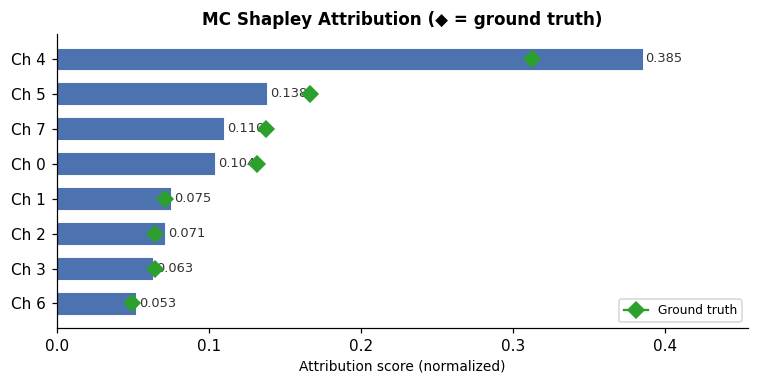

<Axes: title={'center': 'MC Shapley Attribution (◆ = ground truth)'}, xlabel='Attribution score (normalized)'>

In [5]:
mc = fitted['MC Shapley']

# Called directly on the model
mc.plot_attribution(ground_truth=ground_truth, title='MC Shapley Attribution (◆ = ground truth)')

### 4b. Journey sequence diagram

Touchpoints shown as boxes connected by arrows. Box colour encodes the model's attribution weight for that channel. The outcome node (✓/✗) shows conversion status.

Journey 3: ['Ch 5', 'Ch 2', 'Ch 7', 'Ch 0', 'Ch 4', 'Ch 1']  →  converted


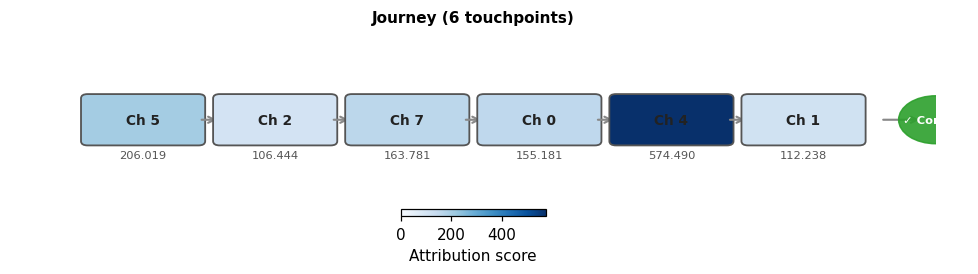

<Axes: title={'center': 'Journey (6 touchpoints)'}>

In [6]:
# Pick an interesting converting journey (one with 4+ touchpoints)
long_converting = [
    (i, j) for i, (j, c) in enumerate(zip(journeys, conversions))
    if c == 1 and len(j) >= 4
]
idx, example_journey = long_converting[0]

print(f"Journey {idx}: {[f'Ch {x}' for x in example_journey]}  →  converted")

# Called directly on the model — boxes are coloured by MC Shapley attribution
mc.plot_journey(example_journey, converted=True)

Journey 1: ['Ch 7', 'Ch 4', 'Ch 2', 'Ch 7', 'Ch 7']  →  no conversion


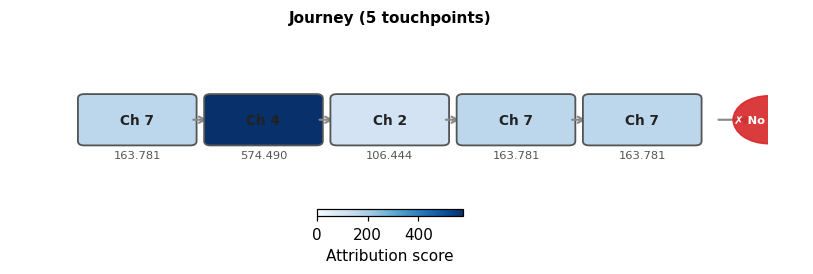

<Axes: title={'center': 'Journey (5 touchpoints)'}>

In [7]:
# A non-converting journey for contrast
non_converting = [(i, j) for i, (j, c) in enumerate(zip(journeys, conversions)) if c == 0 and len(j) >= 3]
idx_nc, journey_nc = non_converting[0]

print(f"Journey {idx_nc}: {[f'Ch {x}' for x in journey_nc]}  →  no conversion")
mc.plot_journey(journey_nc, converted=False)

### 4c. Per-journey attribution heatmap

Heatmap of the `transform()` output matrix. Each row is a journey, each column is a channel. Brighter = higher attribution weight.

---
## 4d. Path Shapley — ordering-aware attribution & directed benchmark

`PathShapleyAttribution` uses the actual journey sequence as the coalition-formation order instead of sampling random permutations. Channel B in journey `[A, B]` is credited for the lift *given A was already seen*; in `[B, A]` it is A that earns that conditional credit.

To properly benchmark this, we generate a **directed dataset** with asymmetric sequential synergies baked into the conversion model (`directed_interaction_strength=0.6`). The oracle ground truth is computed by walking each converting journey through the true logistic model and accumulating prefix-based marginal contributions — this is what PathShapley is designed to recover, and what set-based models (MC Shapley, heuristics) are blind to.

Expected results:
- **Path Shapley**: lowest NMAE against ordered GT — directly models path-based attribution
- **MC Shapley**: worst NMAE — set-based, blind to channel ordering
- **Heuristics**: moderate performance through accidental position correlation

In [8]:
# Dataset with directed (asymmetric) sequential interactions
j_dir, c_dir, gt_dir, ch_dir, ordered_gt = make_attribution_problem(
    n_channels=8,
    n_journeys=5000,
    directed_interaction_strength=0.6,
    random_state=42,
    return_ordered_ground_truth=True,
)

print(f"Journeys: {len(j_dir):,}   Conversions: {c_dir.sum():,} ({c_dir.mean():.1%})")
print()
gt_df = pd.DataFrame({
    'Individual importance (set GT)': gt_dir,
    'Oracle path attribution (ordered GT)': ordered_gt,
}, index=[f'Ch {c}' for c in ch_dir]).round(4)
print("Ground truths (set-based vs ordered):")
gt_df.sort_values('Oracle path attribution (ordered GT)', ascending=False)

Journeys: 5,000   Conversions: 1,511 (30.2%)

Ground truths (set-based vs ordered):


,Individual importance (set GT),Oracle path attribution (ordered GT)
Ch 5,0.1669,0.2745
Ch 4,0.3129,0.1935
Ch 2,0.0647,0.1289
Ch 1,0.0716,0.1236
Ch 7,0.1375,0.1189
Ch 3,0.0647,0.0876
Ch 0,0.1320,0.0654
Ch 6,0.0498,0.0075


In [9]:
# Fit PathShapley and MC Shapley on the directed dataset
t0 = time.perf_counter()
path_model = PathShapleyAttribution(random_state=42).fit(j_dir, y=c_dir)
t_path = time.perf_counter() - t0

t0 = time.perf_counter()
mc_dir = MonteCarloShapleyAttribution(n_iter=2000, random_state=42).fit(j_dir, y=c_dir)
t_mc = time.perf_counter() - t0

print(f"Path Shapley : {t_path:.2f}s")
print(f"MC Shapley   : {t_mc:.2f}s")

Path Shapley : 0.46s
MC Shapley   : 0.48s


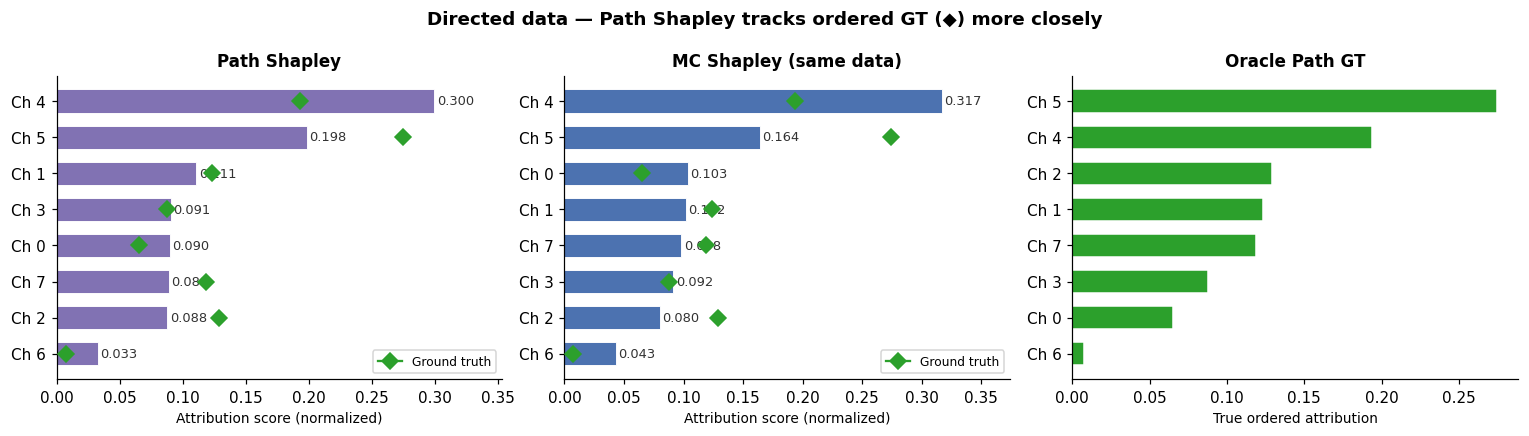

In [10]:
# Attribution bars side by side — Path vs MC vs oracle
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_attribution(path_model, ax=axes[0], title='Path Shapley',
                 ground_truth=ordered_gt, color='#8172B3')
plot_attribution(mc_dir, ax=axes[1], title='MC Shapley (same data)',
                 ground_truth=ordered_gt, color='#4C72B0')

# Oracle ordered ground truth
ch_labels = [f'Ch {c}' for c in ch_dir]
order = np.argsort(ordered_gt)[::-1]
axes[2].barh([ch_labels[i] for i in order][::-1], ordered_gt[order][::-1],
             color='#2ca02c', edgecolor='white', height=0.65)
axes[2].set_title('Oracle Path GT', fontsize=11, fontweight='bold')
axes[2].set_xlabel('True ordered attribution', fontsize=9)
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle('Directed data — Path Shapley tracks ordered GT (◆) more closely',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

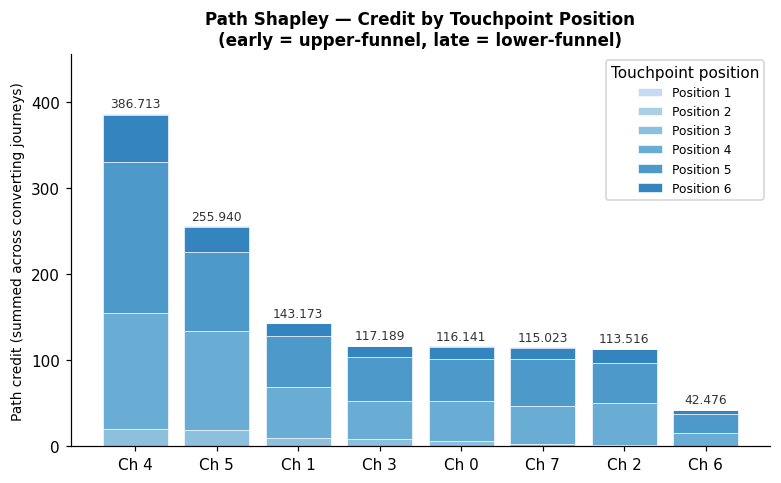

<Axes: title={'center': 'Path Shapley — Credit by Touchpoint Position\n(early = upper-funnel, late = lower-funnel)'}, ylabel='Path credit (summed across converting journeys)'>

In [11]:
# Position attribution — upper-funnel vs lower-funnel
path_model.plot_position_attribution(
    title='Path Shapley — Credit by Touchpoint Position\n(early = upper-funnel, late = lower-funnel)'
)

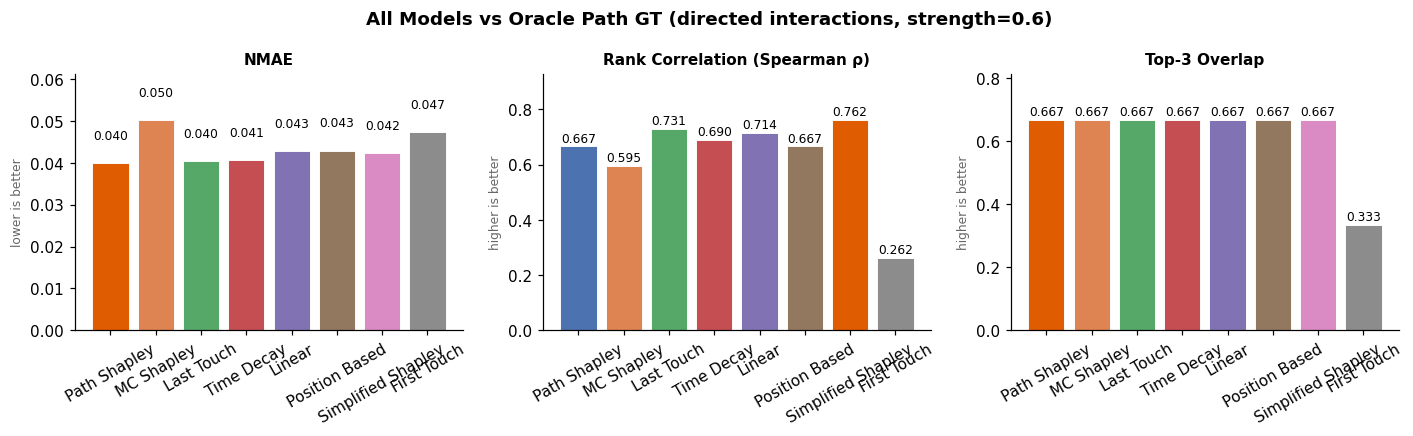

,NMAE ↓,Rank Corr ↑,Top-3 ↑,Overall Rank
Path Shapley,0.0399,0.6667,0.6667,3
Last Touch,0.0404,0.7306,0.6667,1
Time Decay,0.0407,0.6905,0.6667,4
Simplified Shapley,0.0423,0.7619,0.6667,2
Linear,0.0427,0.7143,0.6667,5
Position Based,0.0429,0.6667,0.6667,6
First Touch,0.0474,0.2619,0.3333,8
MC Shapley,0.0503,0.5952,0.6667,7


In [12]:
# Metrics: ALL models vs oracle ordered ground truth on directed dataset
td_dir  = TimeDecayAttribution(decay_rate=0.5).fit(j_dir, y=c_dir)
pb_dir  = PositionBasedAttribution().fit(j_dir, y=c_dir)
ss_dir  = SimplifiedShapleyAttribution().fit(j_dir, y=c_dir)
linear_dir = LinearAttribution().fit(j_dir, y=c_dir)
ft_dir     = FirstTouchAttribution().fit(j_dir, y=c_dir)
lt_dir     = LastTouchAttribution().fit(j_dir, y=c_dir)

all_directed = {
    'Path Shapley'      : path_model,
    'MC Shapley'        : mc_dir,
    'Last Touch'        : lt_dir,
    'Time Decay'        : td_dir,
    'Linear'            : linear_dir,
    'Position Based'    : pb_dir,
    'Simplified Shapley': ss_dir,
    'First Touch'       : ft_dir,
}

results_ordered = attribution_summary(
    {name: m.get_attribution_array() for name, m in all_directed.items()},
    ordered_gt,   # ← oracle ordered ground truth
)

plot_performance(results_ordered,
                 title='All Models vs Oracle Path GT (directed interactions, strength=0.6)')

metrics_ordered = pd.DataFrame(results_ordered).T.round(4)
metrics_ordered.columns = ['NMAE ↓', 'Rank Corr ↑', 'Top-3 ↑']
metrics_ordered['Overall Rank'] = (
    metrics_ordered['NMAE ↓'].rank() +
    metrics_ordered['Rank Corr ↑'].rank(ascending=False) +
    metrics_ordered['Top-3 ↑'].rank(ascending=False)
).rank().astype(int)

metrics_ordered.sort_values('NMAE ↓')

In [13]:
# Full attribution comparison on directed data — all models
ch_labels_dir = [f'Ch {c}' for c in ch_dir]
scores_dir = pd.DataFrame(
    {
        'Set GT'      : gt_dir,
        'Ordered GT'  : ordered_gt,
    } | {name: m.get_attribution_array() for name, m in all_directed.items()},
    index=ch_labels_dir,
).round(4)

scores_dir.sort_values('Ordered GT', ascending=False)

,Set GT,Ordered GT,Path Shapley,MC Shapley,Last Touch,Time Decay,Linear,Position Based,Simplified Shapley,First Touch
Ch 5,0.1669,0.2745,0.1984,0.1644,0.1621,0.1514,0.1386,0.1404,0.1414,0.1198
Ch 4,0.3129,0.1935,0.2997,0.3171,0.1635,0.1746,0.1820,0.1813,0.1797,0.1985
Ch 2,0.0647,0.1289,0.0880,0.0802,0.1145,0.1116,0.1090,0.1105,0.1124,0.1072
Ch 1,0.0716,0.1236,0.1110,0.1020,0.1191,0.1201,0.1199,0.1210,0.1181,0.1238
Ch 7,0.1375,0.1189,0.0892,0.0983,0.1185,0.1218,0.1193,0.1145,0.1186,0.1059
Ch 3,0.0647,0.0876,0.0908,0.0915,0.1185,0.1138,0.1120,0.1115,0.1109,0.1052
Ch 0,0.1320,0.0654,0.0900,0.1034,0.1178,0.1144,0.1171,0.1207,0.1165,0.1271
Ch 6,0.0498,0.0075,0.0329,0.0431,0.0860,0.0923,0.1021,0.1001,0.1022,0.1125


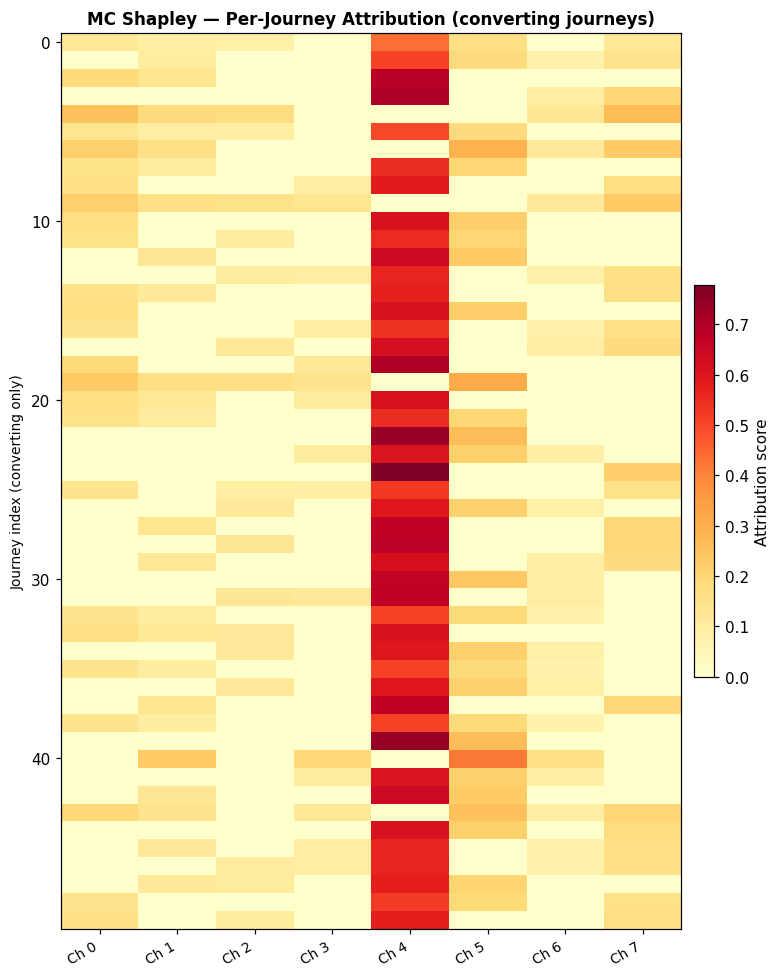

<Axes: title={'center': 'MC Shapley — Per-Journey Attribution (converting journeys)'}, ylabel='Journey index (converting only)'>

In [14]:
# Show only converting journeys (cleaner signal)
mc.plot_journeys_heatmap(
    journeys,
    conversions=conversions,
    max_journeys=50,
    title='MC Shapley — Per-Journey Attribution (converting journeys)',
)

---
## 5. Multi-Model Comparison

### 5a. Grouped attribution bar chart

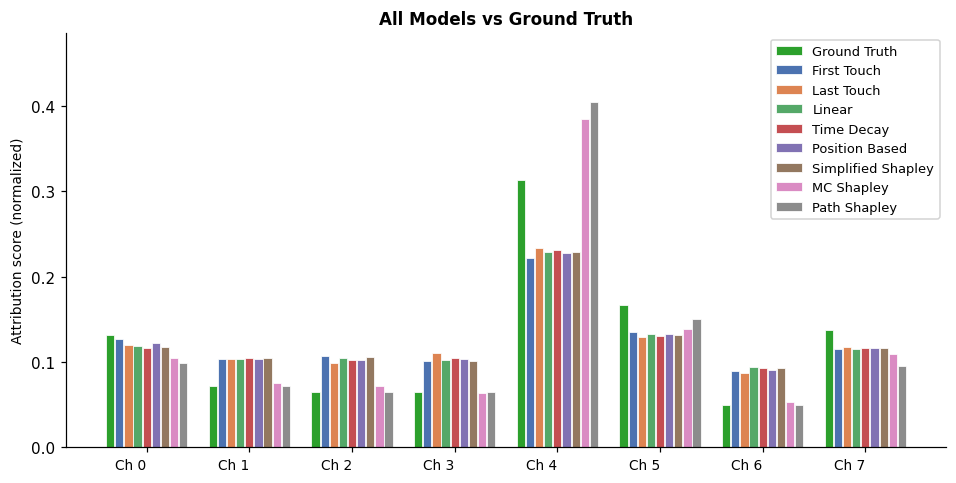

<Axes: title={'center': 'All Models vs Ground Truth'}, ylabel='Attribution score (normalized)'>

In [15]:
# Compare MC Shapley vs all heuristics vs ground truth
compare_models(
    {name: model for name, model in fitted.items()},
    ground_truth=ground_truth,
    title='All Models vs Ground Truth',
)

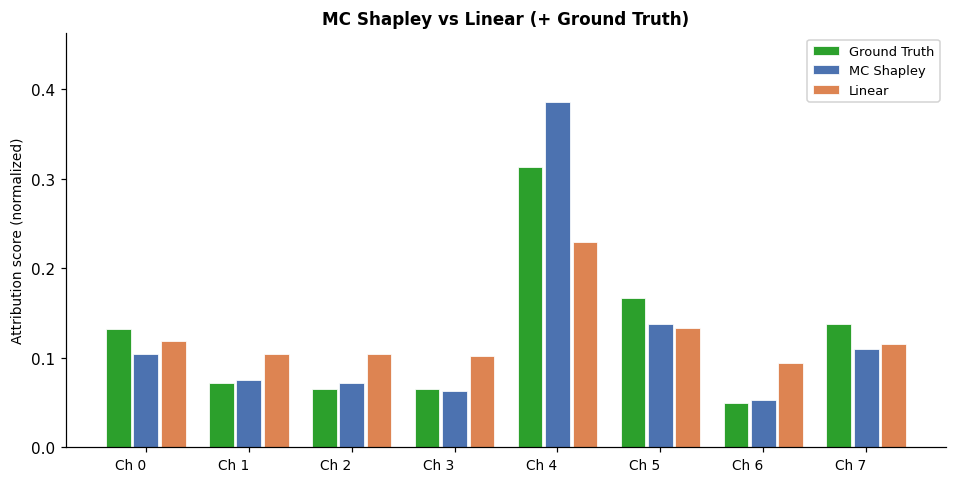

<Axes: title={'center': 'MC Shapley vs Linear (+ Ground Truth)'}, ylabel='Attribution score (normalized)'>

In [16]:
# Focused: just MC Shapley vs Linear vs ground truth
compare_models(
    {'MC Shapley': fitted['MC Shapley'], 'Linear': fitted['Linear']},
    ground_truth=ground_truth,
    title='MC Shapley vs Linear (+ Ground Truth)',
)

### 5b. Performance metrics panel

Three panels: NMAE (lower = better), Spearman rank correlation, top-3 overlap. Highlighted bar = best model in each metric.

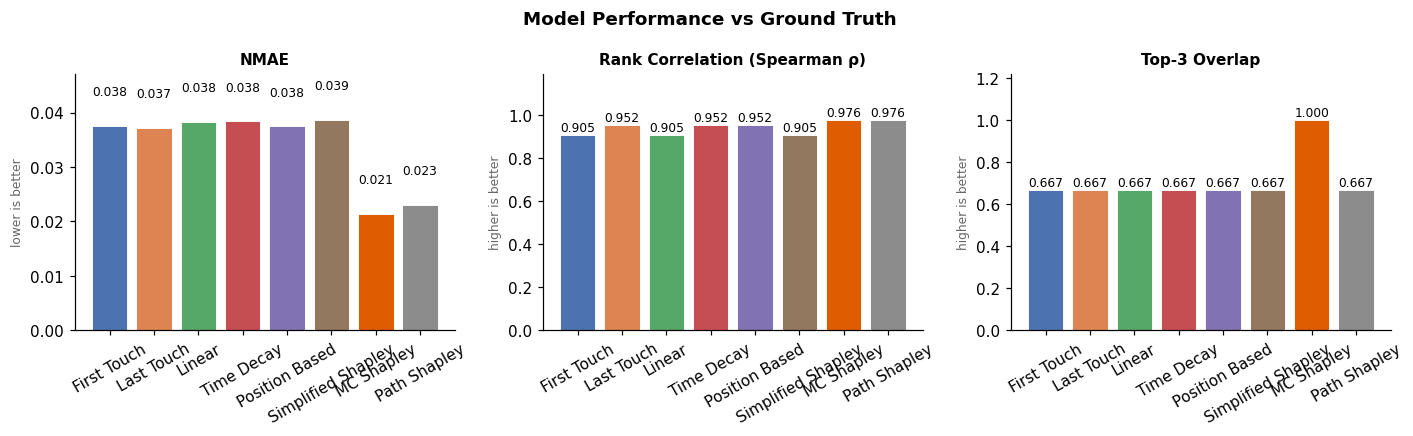

array([<Axes: title={'center': 'NMAE'}, ylabel='lower is better'>,
       <Axes: title={'center': 'Rank Correlation (Spearman ρ)'}, ylabel='higher is better'>,
       <Axes: title={'center': 'Top-3 Overlap'}, ylabel='higher is better'>],
      dtype=object)

In [17]:
results = attribution_summary(
    {name: model.get_attribution_array() for name, model in fitted.items()},
    ground_truth,
)

plot_performance(results, title='Model Performance vs Ground Truth')

### 5c. Attribution scores table

Full numeric comparison: normalized attribution per channel for every model, alongside ground truth.

In [18]:
channel_labels = [f'Ch {c}' for c in channel_names]

scores_df = pd.DataFrame(
    {'Ground Truth': ground_truth}
    | {name: model.get_attribution_array() for name, model in fitted.items()},
    index=channel_labels,
).round(4)

# Sort rows by ground truth importance descending
scores_df.sort_values('Ground Truth', ascending=False)

,Ground Truth,First Touch,Last Touch,Linear,Time Decay,Position Based,Simplified Shapley,MC Shapley,Path Shapley
Ch 4,0.3129,0.2213,0.2334,0.2294,0.2315,0.2279,0.2288,0.3853,0.4044
Ch 5,0.1669,0.1355,0.1294,0.1327,0.1306,0.1331,0.1319,0.1382,0.1508
Ch 7,0.1375,0.1147,0.1180,0.1157,0.1167,0.1165,0.1159,0.1098,0.0954
Ch 0,0.1320,0.1274,0.1194,0.1182,0.1169,0.1217,0.1180,0.1041,0.0985
Ch 1,0.0716,0.1040,0.1033,0.1038,0.1044,0.1038,0.1049,0.0753,0.0718
Ch 2,0.0647,0.1066,0.0986,0.1044,0.1027,0.1028,0.1063,0.0714,0.0647
Ch 3,0.0647,0.1006,0.1107,0.1018,0.1047,0.1040,0.1010,0.0634,0.0652
Ch 6,0.0498,0.0899,0.0872,0.0941,0.0925,0.0902,0.0932,0.0525,0.0492


In [19]:
# Performance metrics table — sorted by NMAE (best first)
metrics_df = pd.DataFrame(results).T.round(4)
metrics_df.columns = ['NMAE ↓', 'Rank Corr ↑', 'Top-3 Overlap ↑']
metrics_df.sort_values('NMAE ↓')

,NMAE ↓,Rank Corr ↑,Top-3 Overlap ↑
MC Shapley,0.0214,0.9762,1.0000
Path Shapley,0.0231,0.9762,0.6667
Last Touch,0.0373,0.9524,0.6667
Position Based,0.0375,0.9524,0.6667
First Touch,0.0376,0.9048,0.6667
Linear,0.0384,0.9048,0.6667
Time Decay,0.0384,0.9524,0.6667
Simplified Shapley,0.0387,0.9048,0.6667


---
## 6. scikit-learn API Compatibility

All models are `BaseEstimator` + `TransformerMixin`, giving full sklearn interoperability.

In [20]:
from sklearn.base import clone

mc = fitted['MC Shapley']

# get_params / set_params
print('get_params():', mc.get_params())

mc2 = mc.set_params(n_iter=500)
print('After set_params(n_iter=500):', mc2.get_params()['n_iter'])

# Deep clone (same hyperparams, unfitted)
cloned = clone(mc)
print('Cloned is_fitted_:', getattr(cloned, 'is_fitted_', False))

get_params(): {'n_iter': 2000, 'normalize': True, 'random_state': 42, 'verbose': True}
After set_params(n_iter=500): 500
Cloned is_fitted_: False


In [21]:
# transform() returns per-journey attribution matrix
matrix = fitted['MC Shapley'].transform(journeys[:5])
print('transform() shape:', matrix.shape)
pd.DataFrame(matrix, columns=channel_labels).round(4)

transform() shape: (5, 8)


,Ch 0,Ch 1,Ch 2,Ch 3,Ch 4,Ch 5,Ch 6,Ch 7
0,0.0000,0.0000,0.0000,0.0,0.8800,0.0000,0.1200,0.0000
1,0.0000,0.0000,0.1260,0.0,0.6801,0.0000,0.0000,0.1939
2,0.0000,0.0000,0.0000,0.0,0.7782,0.0000,0.0000,0.2218
3,0.1177,0.0851,0.0808,0.0,0.4358,0.1563,0.0000,0.1243
4,0.0000,0.0000,0.1402,0.0,0.7567,0.0000,0.1032,0.0000


In [22]:
# fit_transform() in one call
fresh = MonteCarloShapleyAttribution(n_iter=200, random_state=0)
matrix_ft = fresh.fit_transform(journeys[:200], y=conversions[:200])
print('fit_transform() shape:', matrix_ft.shape)
print('Row sums (should be 1.0):', matrix_ft.sum(axis=1)[:5].round(4))

fit_transform() shape: (200, 8)
Row sums (should be 1.0): [1. 1. 1. 1. 1.]


---
## 7. Scalability

MC Shapley scales linearly with `n_channels` and `n_iter` — no exponential blowup. Exact methods (`SimplifiedShapleyAttribution`) enumerate all subsets (2^n), so become impractical beyond ~20 channels.

In [23]:
print(f"{'Channels':>10}  {'MC Shapley':>12}  {'Simplified':>12}")
print('-' * 40)

for n_ch in [5, 8, 12, 20, 50]:
    j, c, _, _ = make_attribution_problem(n_channels=n_ch, n_journeys=1000, random_state=0)

    t0 = time.perf_counter()
    MonteCarloShapleyAttribution(n_iter=500, random_state=0).fit(j, y=c)
    t_mc = time.perf_counter() - t0

    if n_ch <= 15:
        t0 = time.perf_counter()
        SimplifiedShapleyAttribution().fit(j, y=c)
        t_simple = f"{time.perf_counter() - t0:.3f}s"
    else:
        t_simple = 'skipped (2^n)'

    print(f"{n_ch:>10}  {t_mc:>11.3f}s  {t_simple:>12}")

  Channels    MC Shapley    Simplified
----------------------------------------
         5        0.128s        0.001s
         8        0.174s        0.001s
        12        0.385s        0.001s
        20        0.885s  skipped (2^n)
        50        2.473s  skipped (2^n)


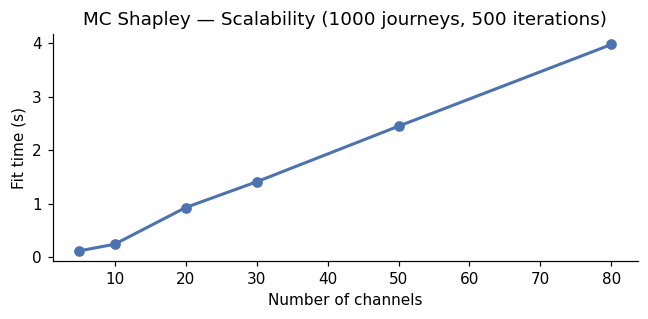

In [24]:
# Runtime vs n_channels (MC only)
ch_range = [5, 10, 20, 30, 50, 80]
times = []

for n_ch in ch_range:
    j, c, _, _ = make_attribution_problem(n_channels=n_ch, n_journeys=1000, random_state=0)
    t0 = time.perf_counter()
    MonteCarloShapleyAttribution(n_iter=500, random_state=0).fit(j, y=c)
    times.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ch_range, times, marker='o', color='#4C72B0', lw=2)
ax.set_xlabel('Number of channels')
ax.set_ylabel('Fit time (s)')
ax.set_title('MC Shapley — Scalability (1000 journeys, 500 iterations)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 8. Final Summary — All Models Head-to-Head

Full comparison on the original 5000-journey dataset with 8 channels.

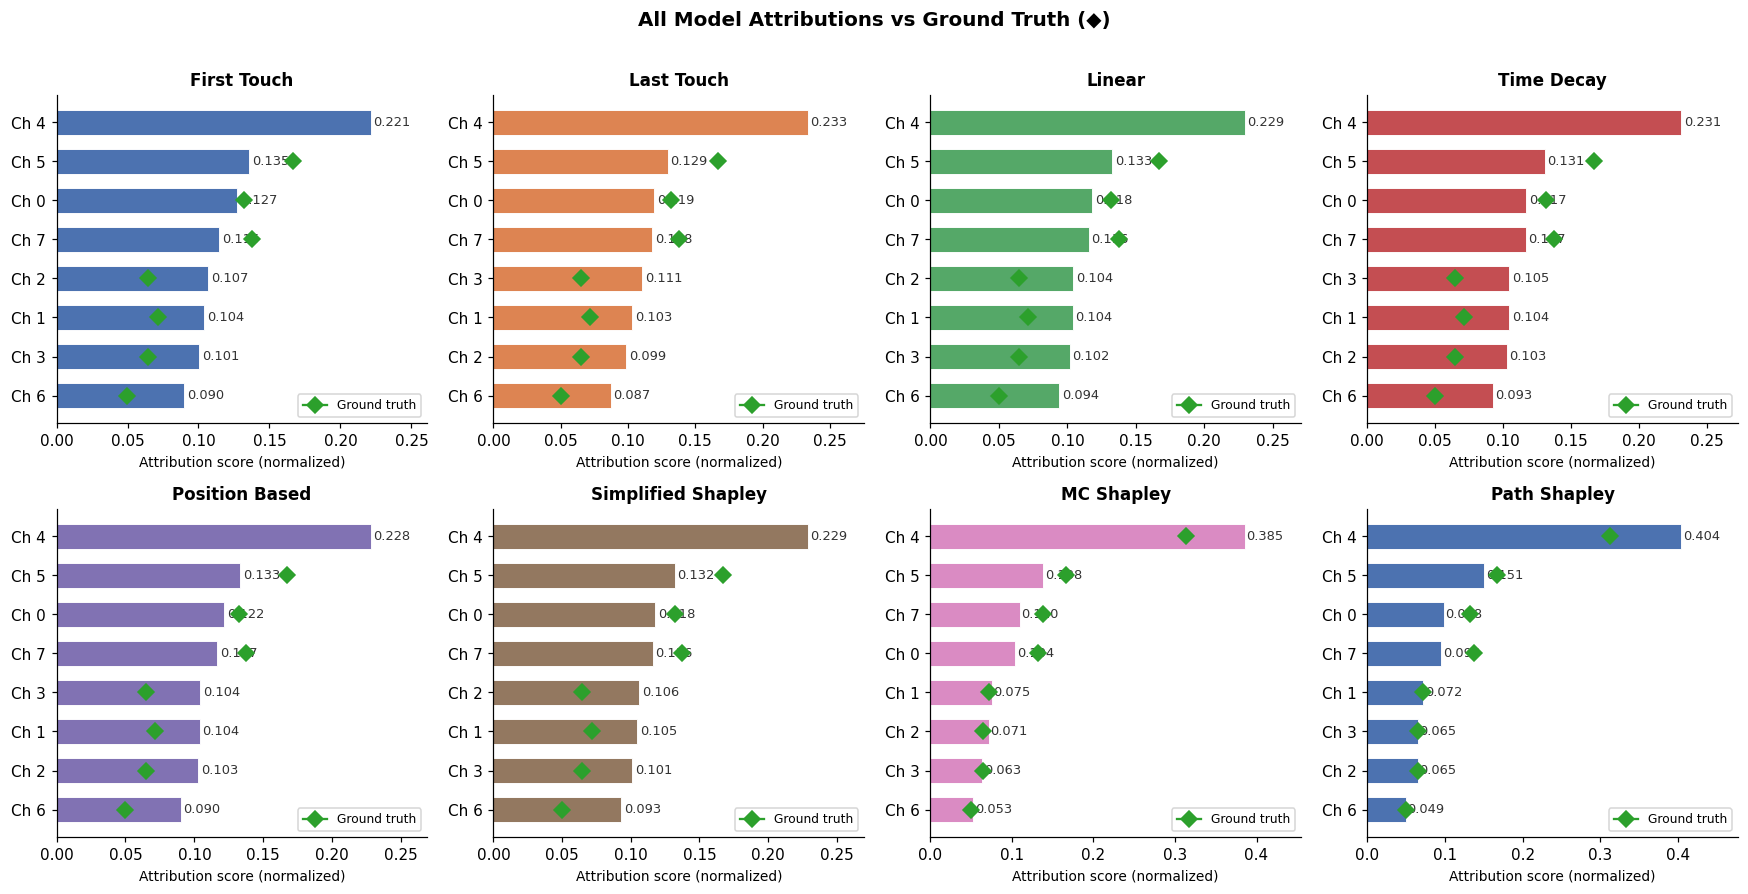

In [25]:
# Side-by-side: per-model attribution bars (4-column grid)
n_models = len(fitted)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes_flat = axes.flatten()

colors = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B3','#937860','#DA8BC3','#4C72B0']

for ax, (name, model), color in zip(axes_flat, fitted.items(), colors):
    plot_attribution(model, ax=ax, title=name,
                     ground_truth=ground_truth, color=color)

# Hide any unused axes
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

fig.suptitle('All Model Attributions vs Ground Truth (◆)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

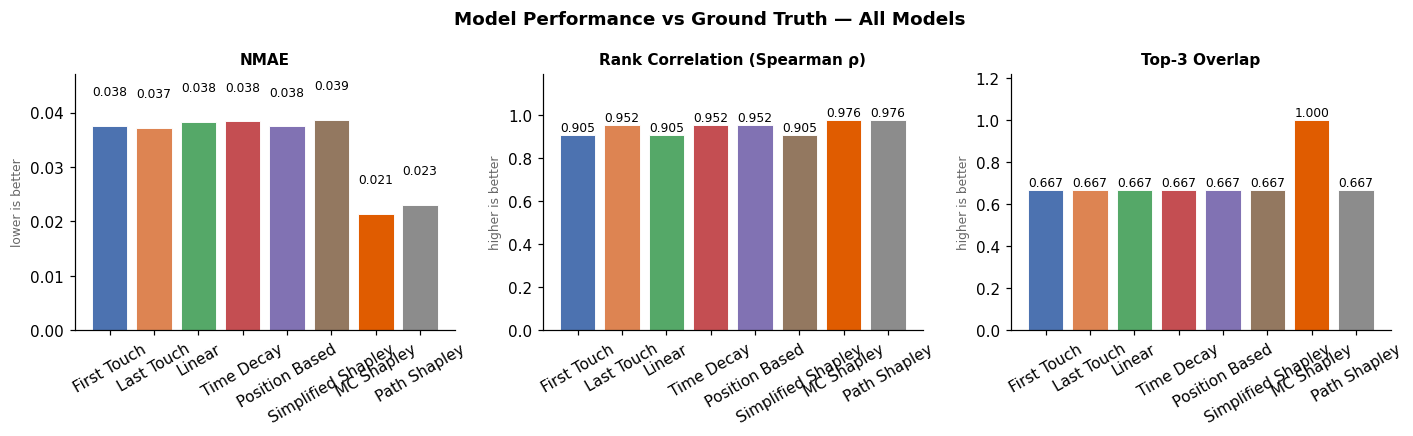

array([<Axes: title={'center': 'NMAE'}, ylabel='lower is better'>,
       <Axes: title={'center': 'Rank Correlation (Spearman ρ)'}, ylabel='higher is better'>,
       <Axes: title={'center': 'Top-3 Overlap'}, ylabel='higher is better'>],
      dtype=object)

In [26]:
# Performance panel — all models
plot_performance(results, title='Model Performance vs Ground Truth — All Models')

In [27]:
# Final rankings table
final_df = pd.DataFrame(results).T.round(4)
final_df.columns = ['NMAE ↓', 'Rank Corr ↑', 'Top-3 ↑']
final_df['Overall Rank'] = (
    final_df['NMAE ↓'].rank() +
    final_df['Rank Corr ↑'].rank(ascending=False) +
    final_df['Top-3 ↑'].rank(ascending=False)
).rank().astype(int)

final_df.sort_values('Overall Rank')

,NMAE ↓,Rank Corr ↑,Top-3 ↑,Overall Rank
MC Shapley,0.0214,0.9762,1.0000,1
Path Shapley,0.0231,0.9762,0.6667,2
Last Touch,0.0373,0.9524,0.6667,3
Position Based,0.0375,0.9524,0.6667,4
Time Decay,0.0384,0.9524,0.6667,5
First Touch,0.0376,0.9048,0.6667,6
Linear,0.0384,0.9048,0.6667,7
Simplified Shapley,0.0387,0.9048,0.6667,8
